In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

real_df = pd.read_csv("../data/users.csv")
fake_df = pd.read_csv("../data/fusers.csv")

print("Real profiles:", real_df.shape)
print("Fake profiles:", fake_df.shape)

Real profiles: (1481, 34)
Fake profiles: (1337, 34)


In [5]:
real_df["label"] = 0
fake_df["label"] = 1

df = pd.concat([real_df, fake_df], ignore_index=True)

print("Final dataset shape:", df.shape)
print("\nClass distribution:")
print(df["label"].value_counts())

Final dataset shape: (2818, 35)

Class distribution:
label
0    1481
1    1337
Name: count, dtype: int64


In [3]:
print(df.columns.tolist())

['id', 'name', 'screen_name', 'statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'created_at', 'url', 'lang', 'time_zone', 'location', 'default_profile', 'default_profile_image', 'geo_enabled', 'profile_image_url', 'profile_banner_url', 'profile_use_background_image', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_background_tile', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'utc_offset', 'protected', 'verified', 'description', 'updated', 'dataset', 'label']


In [4]:
df.head()

,id,name,screen_name,statuses_count,followers_count,friends_count,favourites_count,listed_count,created_at,url,lang,time_zone,location,default_profile,default_profile_image,geo_enabled,profile_image_url,profile_banner_url,profile_use_background_image,profile_background_image_url_https,profile_text_color,profile_image_url_https,profile_sidebar_border_color,profile_background_tile,profile_sidebar_fill_color,profile_background_image_url,profile_background_color,profile_link_color,utc_offset,protected,verified,description,updated,dataset,label
0,3610511,Davide Dellacasa,braddd,20370,5470,2385,145,52,Fri Apr 06 10:58:22 +0000 2007,http://braddd.tumblr.com,it,Rome,Roma,NaN,NaN,NaN,http://a0.twimg.com/profile_images/1575057050/...,https://si0.twimg.com/profile_banners/3610511/...,1.0,https://si0.twimg.com/profile_background_image...,0C3E53,https://si0.twimg.com/profile_images/157505705...,F2E195,NaN,FFF7CC,http://a0.twimg.com/profile_background_images/...,BADFCD,FF0000,3600.0,NaN,NaN,Founder of http://www.screenweek.it & http://w...,2015-02-14 10:54:49,E13,0
1,5656162,Simone Economo,eKoeS,3131,506,381,9,40,Mon Apr 30 15:08:42 +0000 2007,http://www.lineheight.net/,en,Rome,"Rome, Italy",NaN,NaN,NaN,http://a0.twimg.com/profile_images/1901298312/...,NaN,1.0,https://si0.twimg.com/images/themes/theme1/bg.png,333333,https://si0.twimg.com/profile_images/190129831...,FFFFFF,NaN,DDEEF6,http://a0.twimg.com/images/themes/theme1/bg.png,C0DEED,0084B4,3600.0,NaN,NaN,BSc degree (cum laude) in Computer Engineering...,2015-02-14 10:54:49,E13,0
2,5682702,tacone,tacone_,4024,264,87,323,16,Tue May 01 11:53:40 +0000 2007,http://t.co/LKrl1dZE,en,Rome,Internets,NaN,NaN,NaN,http://a0.twimg.com/profile_images/1640620850/...,https://si0.twimg.com/profile_banners/5682702/...,1.0,https://si0.twimg.com/profile_background_image...,666666,https://si0.twimg.com/profile_images/164062085...,181A1E,1.0,000000,http://a0.twimg.com/profile_background_images/...,1A1B1F,2FC2EF,3600.0,NaN,NaN,Cogito ergo bestemmio.,2015-02-14 10:54:49,E13,0
3,6067292,alesaura,alesstar,40586,640,622,1118,32,Tue May 15 16:55:16 +0000 2007,http://alesstar.wordpress.com/,en,Rome,NaN,NaN,NaN,1.0,http://a0.twimg.com/profile_images/2797534662/...,https://si0.twimg.com/profile_banners/6067292/...,1.0,https://si0.twimg.com/images/themes/theme4/bg.gif,3C3940,https://si0.twimg.com/profile_images/279753466...,FFFFFF,NaN,95E8EC,http://a0.twimg.com/images/themes/theme4/bg.gif,0099B9,0099B9,3600.0,NaN,NaN,"Se la vita ti dà sarde, scapocciale!",2015-02-14 10:54:49,E13,0
4,6015122,Angelo,PerDiletto,2016,62,64,13,0,Sun May 13 19:52:00 +0000 2007,http://www.flickr.com/per_diletto,it,Rome,"iPhone: 44.069630,12.569966",NaN,NaN,1.0,http://a0.twimg.com/profile_images/1073412966/...,NaN,1.0,https://si0.twimg.com/images/themes/theme18/bg...,333333,https://si0.twimg.com/profile_images/107341296...,EEEEEE,NaN,F6F6F6,http://a0.twimg.com/images/themes/theme18/bg.gif,ACDED6,038543,3600.0,NaN,NaN,Je me souviens,2015-02-14 10:54:49,E13,0


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2818 entries, 0 to 2817
Data columns (total 35 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   id                                  2818 non-null   int64  
 1   name                                2818 non-null   str    
 2   screen_name                         2818 non-null   str    
 3   statuses_count                      2818 non-null   int64  
 4   followers_count                     2818 non-null   int64  
 5   friends_count                       2818 non-null   int64  
 6   favourites_count                    2818 non-null   int64  
 7   listed_count                        2818 non-null   int64  
 8   created_at                          2818 non-null   str    
 9   url                                 463 non-null    object 
 10  lang                                2818 non-null   str    
 11  time_zone                           1069 non-null   st

In [7]:
df.describe()

,id,statuses_count,followers_count,friends_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,profile_use_background_image,profile_background_tile,utc_offset,protected,verified,label
count,2.818000e+03,2818.000000,2818.000000,2818.000000,2818.000000,2818.000000,1728.0,8.0,721.0,2760.0,489.0,1069.000000,0.0,0.0,2818.000000
mean,5.374889e+08,1672.198368,371.105039,395.363023,234.541164,2.818666,1.0,1.0,1.0,1.0,1.0,1478.391020,NaN,NaN,0.474450
std,2.977005e+08,4884.669157,8022.631339,465.694322,1445.847248,23.480430,0.0,0.0,0.0,0.0,0.0,8108.211889,NaN,NaN,0.499435
min,3.610511e+06,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,-39600.000000,NaN,NaN,0.000000
25%,3.620867e+08,35.000000,17.000000,168.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,3600.000000,NaN,NaN,0.000000
50%,6.162253e+08,77.000000,26.000000,306.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,1.0,3600.000000,NaN,NaN,0.000000
75%,6.177673e+08,1087.750000,111.000000,519.000000,37.000000,1.000000,1.0,1.0,1.0,1.0,1.0,3600.000000,NaN,NaN,1.000000
max,1.391998e+09,79876.000000,408372.000000,12773.000000,44349.000000,744.000000,1.0,1.0,1.0,1.0,1.0,36000.000000,NaN,NaN,1.000000


In [6]:
missing = df.isnull().sum().sort_values(ascending=False)

print(missing)

verified                              2818
protected                             2818
default_profile_image                 2810
url                                   2355
profile_background_tile               2329
geo_enabled                           2097
profile_banner_url                    1831
utc_offset                            1749
time_zone                             1749
default_profile                       1090
location                               547
description                            271
profile_use_background_image            58
id                                       0
name                                     0
screen_name                              0
lang                                     0
listed_count                             0
created_at                               0
profile_image_url                        0
statuses_count                           0
friends_count                            0
followers_count                          0
favourites_

In [7]:
missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": missing_percent
})

missing_table

,Missing Count,Missing Percentage
created_at,0,0.000000
dataset,0,0.000000
default_profile,1090,38.679915
default_profile_image,2810,99.716111
description,271,9.616749
favourites_count,0,0.000000
followers_count,0,0.000000
friends_count,0,0.000000
geo_enabled,2097,74.414478
id,0,0.000000


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Duplicate IDs:", df["id"].duplicated().sum())

Duplicate IDs: 0


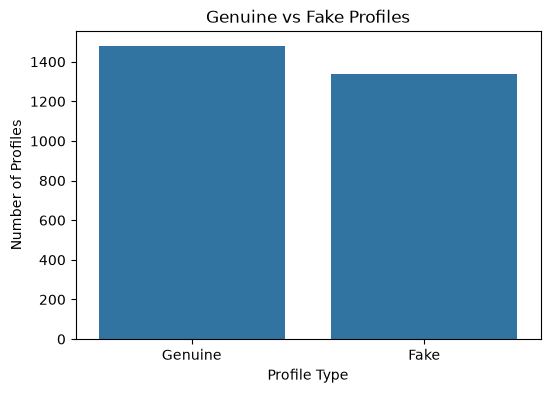

In [10]:
plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="label")

plt.title("Genuine vs Fake Profiles")
plt.xlabel("Profile Type")
plt.ylabel("Number of Profiles")

plt.xticks([0, 1], ["Genuine", "Fake"])

plt.show()

In [11]:
numeric_columns = df.select_dtypes(include=np.number).columns

print(numeric_columns.tolist())

['id', 'statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'default_profile', 'default_profile_image', 'geo_enabled', 'profile_use_background_image', 'profile_background_tile', 'utc_offset', 'protected', 'verified', 'label']


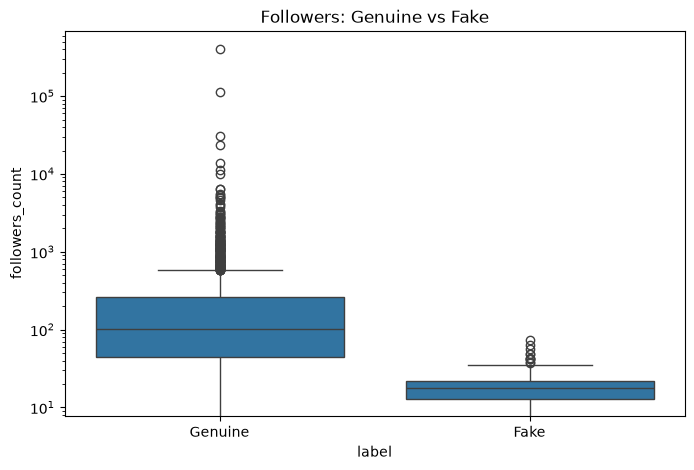

In [12]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label", y="followers_count")

plt.yscale("log")

plt.xticks([0, 1], ["Genuine", "Fake"])

plt.title("Followers: Genuine vs Fake")

plt.show()

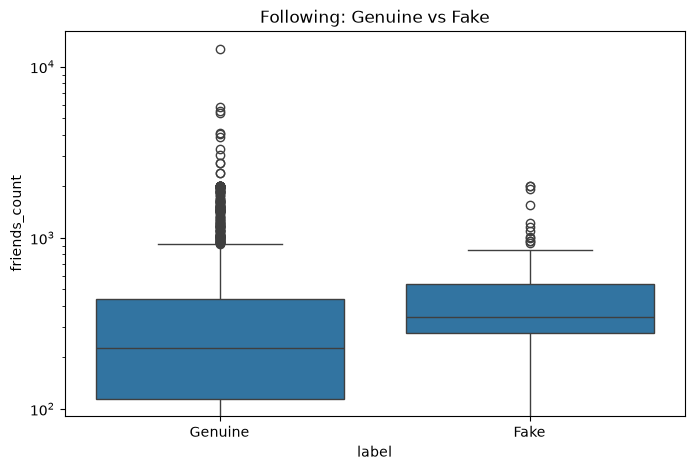

In [13]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label", y="friends_count")

plt.yscale("log")

plt.xticks([0, 1], ["Genuine", "Fake"])

plt.title("Following: Genuine vs Fake")

plt.show()

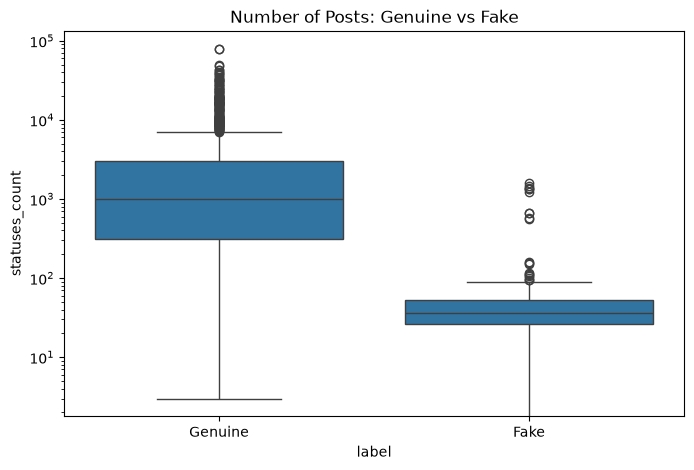

In [14]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label", y="statuses_count")

plt.yscale("log")

plt.xticks([0, 1], ["Genuine", "Fake"])

plt.title("Number of Posts: Genuine vs Fake")

plt.show()

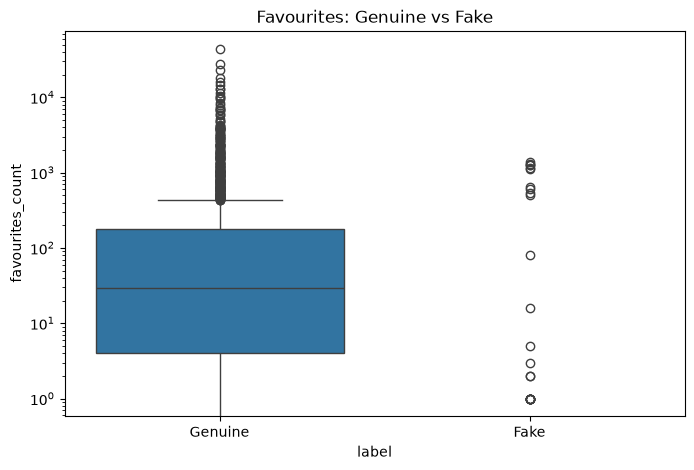

In [15]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="label", y="favourites_count")

plt.yscale("log")

plt.xticks([0, 1], ["Genuine", "Fake"])

plt.title("Favourites: Genuine vs Fake")

plt.show()

In [16]:
df["followers_friends_ratio"] = (
    df["followers_count"] /
    (df["friends_count"] + 1)
)

df["followers_friends_ratio"].describe()

count    2818.000000
mean        1.275907
std        39.652003
min         0.000000
25%         0.044719
50%         0.139698
75%         0.466318
max      2094.215385
Name: followers_friends_ratio, dtype: float64

In [17]:
df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce"
)

print(df["created_at"].head())

0   2007-04-06 10:58:22+00:00
1   2007-04-30 15:08:42+00:00
2   2007-05-01 11:53:40+00:00
3   2007-05-15 16:55:16+00:00
4   2007-05-13 19:52:00+00:00
Name: created_at, dtype: datetime64[us, UTC]


C:\Users\MURAR\AppData\Local\Temp\ipykernel_5564\2649437641.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["created_at"] = pd.to_datetime(


In [18]:
# Convert created_at to timezone-aware datetime
df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce",
    utc=True
)

# Make reference date timezone-aware
reference_date = pd.Timestamp("2016-01-01", tz="UTC")

# Calculate account age
df["account_age_days"] = (
    reference_date - df["created_at"]
).dt.days

# Check result
df["account_age_days"].describe()

count    2818.000000
mean     1490.616395
std       399.503664
min       975.000000
25%      1284.000000
50%      1286.000000
75%      1588.500000
max      3191.000000
Name: account_age_days, dtype: float64

In [19]:
df["statuses_per_day"] = (
    df["statuses_count"] /
    (df["account_age_days"] + 1)
)

In [20]:
df["favourites_per_day"] = (
    df["favourites_count"] /
    (df["account_age_days"] + 1)
)

In [21]:
print(df.columns.tolist())

['id', 'name', 'screen_name', 'statuses_count', 'followers_count', 'friends_count', 'favourites_count', 'listed_count', 'created_at', 'url', 'lang', 'time_zone', 'location', 'default_profile', 'default_profile_image', 'geo_enabled', 'profile_image_url', 'profile_banner_url', 'profile_use_background_image', 'profile_background_image_url_https', 'profile_text_color', 'profile_image_url_https', 'profile_sidebar_border_color', 'profile_background_tile', 'profile_sidebar_fill_color', 'profile_background_image_url', 'profile_background_color', 'profile_link_color', 'utc_offset', 'protected', 'verified', 'description', 'updated', 'dataset', 'label', 'followers_friends_ratio', 'account_age_days', 'statuses_per_day', 'favourites_per_day']


In [22]:
df["has_description"] = df["description"].notna().astype(int)

df["has_location"] = df["location"].notna().astype(int)

df["has_url"] = df["url"].notna().astype(int)

In [23]:
new_features = [
    "followers_friends_ratio",
    "account_age_days",
    "statuses_per_day",
    "favourites_per_day",
    "has_description",
    "has_location",
    "has_url"
]

df[new_features].describe()

,followers_friends_ratio,account_age_days,statuses_per_day,favourites_per_day,has_description,has_location,has_url
count,2818.000000,2818.000000,2818.000000,2818.000000,2818.000000,2818.000000,2818.000000
mean,1.275907,1490.616395,0.944150,0.150869,0.903833,0.805891,0.164301
std,39.652003,399.503664,2.727143,1.009816,0.294873,0.395584,0.370614
min,0.000000,975.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.044719,1284.000000,0.027221,0.000000,1.000000,1.000000,0.000000
50%,0.139698,1286.000000,0.055944,0.000000,1.000000,1.000000,0.000000
75%,0.466318,1588.500000,0.665724,0.021493,1.000000,1.000000,0.000000
max,2094.215385,3191.000000,56.358273,34.947991,1.000000,1.000000,1.000000


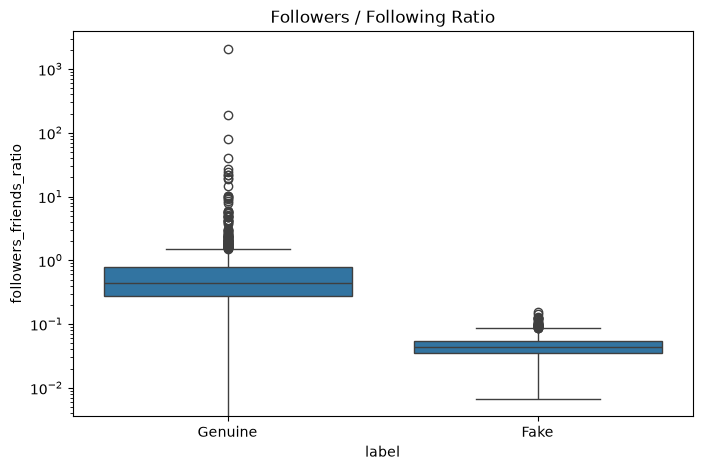

In [24]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="followers_friends_ratio"
)

plt.yscale("log")

plt.xticks([0, 1], ["Genuine", "Fake"])

plt.title("Followers / Following Ratio")

plt.show()

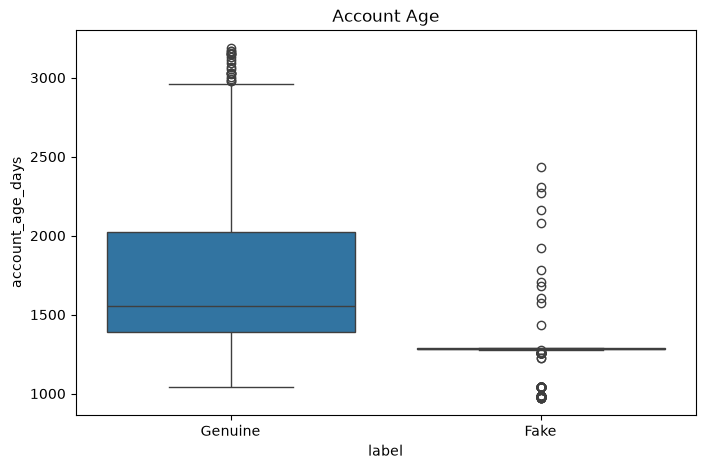

In [25]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="label",
    y="account_age_days"
)

plt.xticks([0, 1], ["Genuine", "Fake"])

plt.title("Account Age")

plt.show()

In [26]:
features = [
    "followers_count",
    "friends_count",
    "statuses_count",
    "favourites_count",
    "listed_count",

    "followers_friends_ratio",
    "account_age_days",
    "statuses_per_day",
    "favourites_per_day",

    "has_description",
    "has_location",
    "has_url"
]

In [27]:
X = df[features]
y = df["label"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2818, 12)
y shape: (2818,)


In [28]:
print(X.isnull().sum())

followers_count            0
friends_count              0
statuses_count             0
favourites_count           0
listed_count               0
followers_friends_ratio    0
account_age_days           0
statuses_per_day           0
favourites_per_day         0
has_description            0
has_location               0
has_url                    0
dtype: int64


In [29]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_imputed = imputer.fit_transform(X)

X = pd.DataFrame(
    X_imputed,
    columns=features
)

print(X.isnull().sum().sum())

0


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2254, 12)
Testing data: (564, 12)


In [31]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [32]:
y_pred = model.predict(X_test)

y_prob = model.predict_proba(X_test)[:, 1]

In [33]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.9929078014184397
Precision: 0.9962406015037594
Recall   : 0.9888059701492538
F1 Score : 0.9925093632958801
ROC-AUC  : 0.9998487293263413


In [34]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Genuine", "Fake"]
))

              precision    recall  f1-score   support

     Genuine       0.99      1.00      0.99       296
        Fake       1.00      0.99      0.99       268

    accuracy                           0.99       564
   macro avg       0.99      0.99      0.99       564
weighted avg       0.99      0.99      0.99       564



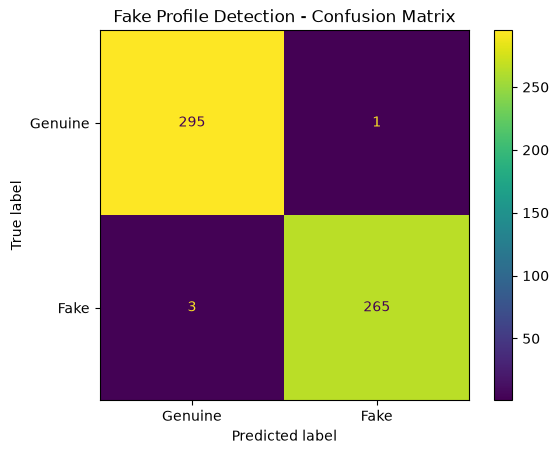

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Genuine", "Fake"]
)

disp.plot()

plt.title("Fake Profile Detection - Confusion Matrix")
plt.show()

In [36]:
importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
5,followers_friends_ratio,0.324899
2,statuses_count,0.199499
7,statuses_per_day,0.127192
8,favourites_per_day,0.109788
3,favourites_count,0.086672
6,account_age_days,0.076272
0,followers_count,0.049790
1,friends_count,0.011827
4,listed_count,0.006787
10,has_location,0.002955


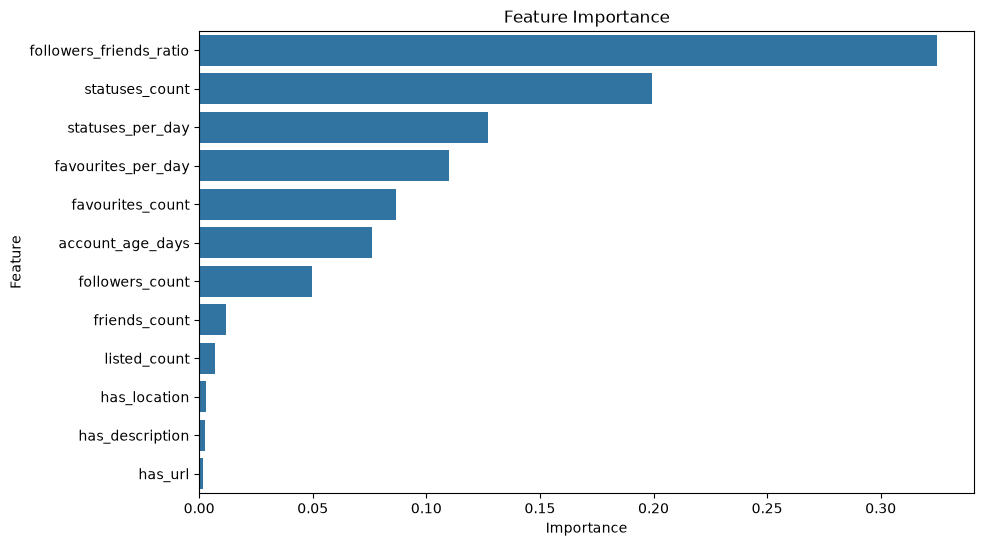

In [37]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

In [38]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(model, "../models/fake_profile_model.pkl")

joblib.dump(imputer, "../models/imputer.pkl")

joblib.dump(features, "../models/features.pkl")

print("Model saved successfully.")

Model saved successfully.
